# Notebook 02 — Traffic Dataset Validation and Suitability Assessment

## Objective
Assess whether the traffic dataset is sufficiently complete, stable, and representative for capstone forecasting and signal-optimization analysis.

## Background / Context
This notebook evaluates temporal coverage, spatial coverage, missingness, and count-duration consistency for the Toronto SVC summary dataset. The goal is to justify dataset suitability before heavier modeling and operational conclusions are drawn.

## Methodology
Validation is performed through descriptive profiling, year-wise and location-wise coverage checks, missing-value diagnostics, and count-duration analysis.

## Implementation
The following sections execute each validation stage and document evidence for dataset suitability and known limitations.

## Background / Context — Scope and Limitation
This is a data-quality and suitability audit. It does not modify preprocessing outputs or modeling logic. The findings support defensible use of the 2015-2019 baseline period for downstream forecasting and signal analysis.

## Implementation — Dataset Overview

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

project_root = Path.cwd()
if not (project_root / "data").exists():
    project_root = project_root.parent

processed_candidates = [
    project_root / "data" / "processed" / "svc_summary_clean.csv",
    project_root / "data" / "processed" / "traffic_summary_eda_ready.csv",
]
fallback_path = project_root / "data" / "raw" / "traffic" / "svc_summary_data.csv"
legacy_fallback_path = project_root / "data" / "raw" / "svc_summary_data.csv"

required_validation_fields = {"count_duration", "avg_wkdy_pm_peak_vol", "count_date_start"}

data_path = fallback_path if fallback_path.exists() else legacy_fallback_path
for cand in processed_candidates:
    if cand.exists():
        cols = pd.read_csv(cand, nrows=1).columns
        if required_validation_fields.issubset(set(cols)):
            data_path = cand
            break

df = pd.read_csv(data_path)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})


In [2]:
print(f"Loaded data from: {data_path.relative_to(project_root)}")
print(f"Dataset shape: {df.shape}")

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nPreview:")
display(df.head())


Loaded data from: data/raw/traffic/svc_summary_data.csv
Dataset shape: (44470, 21)

Columns:
['_id', 'count_id', 'count_type', 'count_date_start', 'count_date_end', 'count_duration', 'location_name', 'longitude', 'latitude', 'centreline_id', 'avg_daily_vol', 'avg_weekday_daily_vol', 'avg_weekend_daily_vol', 'avg_wkdy_am_peak_start', 'avg_wkdy_am_peak_vol', 'avg_wkdy_pm_peak_start', 'avg_wkdy_pm_peak_vol', 'avg_speed', 'avg_85th_percentile_speed', 'avg_95th_percentile_speed', 'avg_heavy_pct']

Data types:


,dtype
_id,int64
count_id,int64
count_type,str
count_date_start,str
count_date_end,str
count_duration,int64
location_name,str
longitude,float64
latitude,float64
centreline_id,int64



Preview:


,_id,count_id,count_type,count_date_start,count_date_end,count_duration,location_name,longitude,latitude,centreline_id,...,avg_weekday_daily_vol,avg_weekend_daily_vol,avg_wkdy_am_peak_start,avg_wkdy_am_peak_vol,avg_wkdy_pm_peak_start,avg_wkdy_pm_peak_vol,avg_speed,avg_85th_percentile_speed,avg_95th_percentile_speed,avg_heavy_pct
0,1,3014976,ATR_SPEED_VOLUME,2026-01-20,2026-01-22,72,Senlac Rd: Churchill Ave - Horsham Ave,-79.427870,43.770960,438812,...,7233.0,NaN,08:15:00,638.0,16:15:00,747.0,37.3,43.9,48.5,NaN
1,2,3015033,ATR_SPEED_VOLUME,2026-01-20,2026-01-22,72,Beachell St: Eglinton Ave E - Luella St,-79.222513,43.743367,110508,...,828.7,NaN,08:00:00,71.0,16:15:00,80.0,31.0,39.8,44.6,NaN
2,3,3015251,ATR_SPEED_VOLUME,2026-01-20,2026-01-22,72,Brookshire Blvd: Lanewood Cres - Blairwood Ter,-79.325944,43.803354,104810,...,341.7,NaN,08:15:00,45.0,18:00:00,30.0,29.3,38.4,44.0,NaN
3,4,3015035,ATR_SPEED_VOLUME,2026-01-20,2026-01-22,72,Dufferin St: Wenderly Dr - Claver Ave,-79.454170,43.711550,9655343,...,29086.7,NaN,08:00:00,2186.0,16:45:00,2070.0,40.4,51.5,57.2,NaN
4,5,3015036,ATR_SPEED_VOLUME,2026-01-20,2026-01-22,72,Bremner Blvd: Olympic Park Trl - Rees St,-79.386180,43.641902,30106817,...,6648.3,NaN,08:30:00,490.0,17:00:00,548.0,29.9,38.4,43.8,NaN


The summary dataset includes traffic count records, location identifiers, geospatial coordinates, count durations, and volume-related summary metrics. Even though the optimization notebooks use raw-derived datasets, these summary fields still help verify whether Toronto's pre-COVID monitoring program provides enough recurring demand coverage for defensible baseline analysis.

## Results — Temporal Coverage Analysis

Temporal range (count_date_start): 1993 to 2026

Observations per year:


,observations
year,
1993.0,1836
1994.0,1062
1995.0,992
1996.0,1324
1997.0,321
1998.0,1294
1999.0,1406
2000.0,569
2001.0,1527


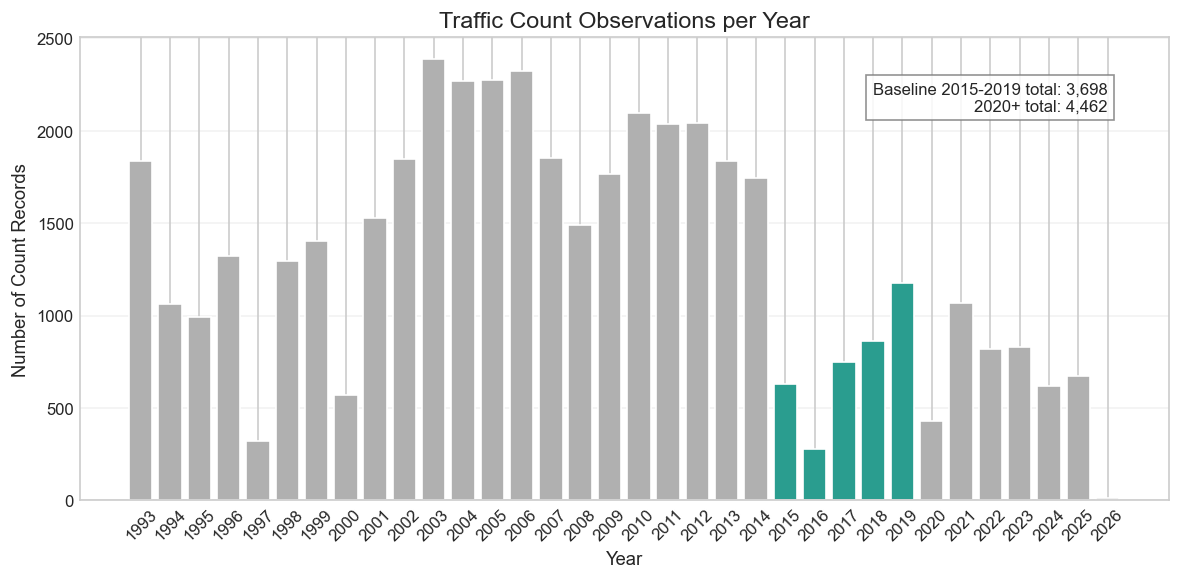

In [3]:
df["count_date_start"] = pd.to_datetime(df["count_date_start"], errors="coerce")

valid_date_mask = df["count_date_start"].notna()
df.loc[valid_date_mask, "year"] = df.loc[valid_date_mask, "count_date_start"].dt.year
df.loc[valid_date_mask, "month"] = df.loc[valid_date_mask, "count_date_start"].dt.month

year_min = int(df.loc[valid_date_mask, "year"].min())
year_max = int(df.loc[valid_date_mask, "year"].max())

yearly_obs = (
    df.loc[valid_date_mask]
    .groupby("year")
    .size()
    .sort_index()
    .astype("int64")
)

print(f"Temporal range (count_date_start): {year_min} to {year_max}")
print("\nObservations per year:")
display(yearly_obs.to_frame("observations"))

years = yearly_obs.index.astype(int).tolist()
year_labels = [str(year) for year in years]
obs = yearly_obs.astype(float).to_numpy()

# Highlight the pre-COVID baseline window (2015-2019) so the audience can see where the stable period is.
colors = ["#2a9d8f" if 2015 <= year <= 2019 else "#b0b0b0" for year in years]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(year_labels, obs, color=colors)
ax.set_title("Traffic Count Observations per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Count Records")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.25)

# Annotate key summary values
baseline_tot = int(yearly_obs.loc[2015:2019].sum()) if 2019 in yearly_obs.index else 0
post2020_tot = int(yearly_obs.loc[yearly_obs.index >= 2020].sum())
text_x = len(year_labels) - 1
text_y = float(max(obs) * 0.95) if len(obs) > 0 else 0.0
ax.text(
    text_x,
    text_y,
    (
        f"Baseline 2015-2019 total: {baseline_tot:,}\n"
        f"2020+ total: {post2020_tot:,}"
    ),
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.85, edgecolor="gray"),
    fontsize=10,
)

plt.tight_layout()
plt.show()


### Visual Description
The first chart shows how many count records are collected each year, with the pre-COVID baseline window (2015–2019) highlighted in green. The second chart plots how many unique locations were sampled each year and the geographic footprint of the sampled points.

### Insight
The year-by-year count chart quickly reveals whether the dataset has consistent coverage in the baseline window and how measurement effort changes after 2020. The spatial plot shows whether monitoring is widespread or concentrated in a few corridors, which affects how representative the demand estimates are for corridor-level signal timing analysis.

Year coverage matters here as a measure of **recurring traffic demand coverage** rather than forecasting depth. The key question is whether the dataset contains a stable enough pre-COVID window to estimate typical peak demand patterns for later optimization experiments.

## Why 2015-2019 Is the Baseline

In [4]:
baseline_mask = df["year"].between(2015, 2019, inclusive="both")
post_2020_mask = df["year"] >= 2020

baseline_summary = pd.DataFrame(
    {
        "period": ["2015-2019 baseline", "2020+ counts"],
        "observations": [int(baseline_mask.sum()), int(post_2020_mask.sum())],
        "unique_locations": [
            df.loc[baseline_mask, "location_name"].nunique(dropna=True),
            df.loc[post_2020_mask, "location_name"].nunique(dropna=True),
        ],
    }
)

display(baseline_summary)


,period,observations,unique_locations
0,2015-2019 baseline,3698,2932
1,2020+ counts,4462,3575


The 2015-2019 window is acceptable because it captures continuous pre-COVID traffic behavior before pandemic-era travel disruption. Sparse or irregular 2020+ observations are still useful as metadata, but they are not a strong basis for continuous forecasting and do not invalidate the use of 2015-2019 as a baseline for optimization-oriented analysis.

## Results — Spatial Coverage Analysis

Unique traffic count locations: 14109

Unique locations per year:


,unique_locations
year,
1993.0,1568
1994.0,933
1995.0,665
1996.0,1145
1997.0,130
1998.0,245
1999.0,134
2000.0,473
2001.0,1207


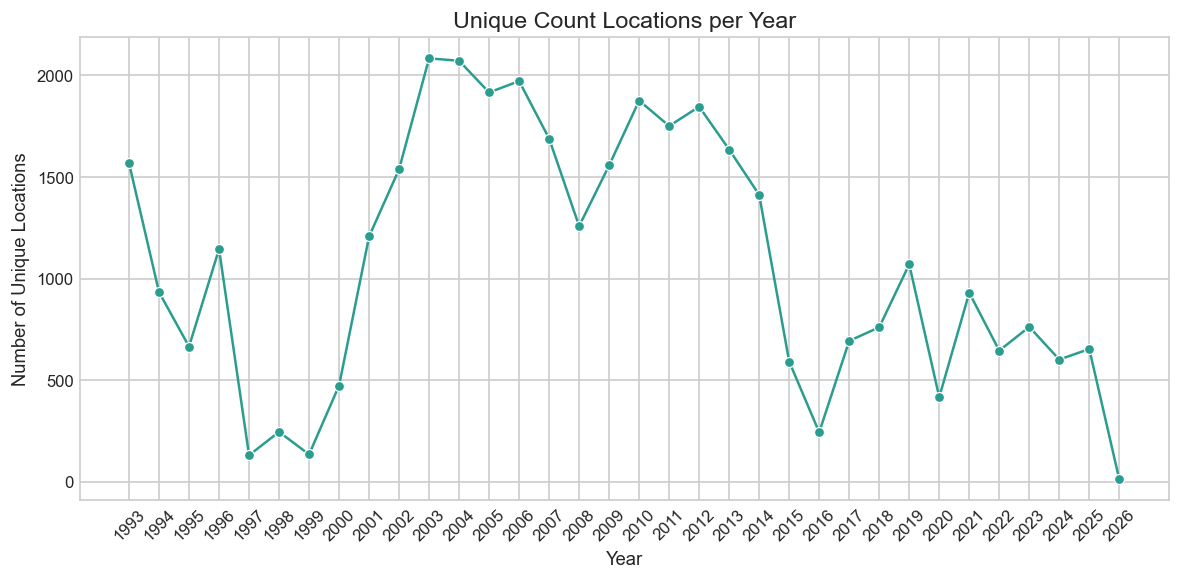

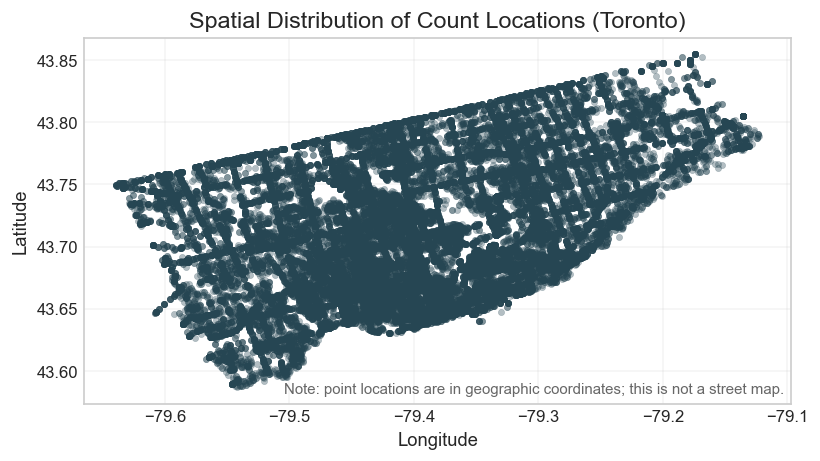

In [5]:
unique_locations = df["location_name"].nunique(dropna=True)

locations_per_year = (
    df.loc[df["year"].notna()]
    .groupby("year")["location_name"]
    .nunique()
    .sort_index()
    .astype("int64")
)

print(f"Unique traffic count locations: {unique_locations}")
print("\nUnique locations per year:")
display(locations_per_year.to_frame("unique_locations"))

plt.figure(figsize=(10, 5))
sns.lineplot(x=locations_per_year.index.astype(int), y=locations_per_year.values, marker="o", color="#2a9d8f")
plt.title("Unique Count Locations per Year")
plt.xlabel("Year")
plt.ylabel("Number of Unique Locations")
plt.xticks(locations_per_year.index.astype(int), rotation=45)
plt.tight_layout()
plt.show()

if {"latitude", "longitude"}.issubset(df.columns):
    geo_df = df[["latitude", "longitude"]].dropna()
    fig, ax = plt.subplots(figsize=(7, 7))
    sns.scatterplot(
        data=geo_df,
        x="longitude",
        y="latitude",
        s=14,
        alpha=0.35,
        color="#264653",
        edgecolor=None,
        ax=ax,
    )
    ax.set_title("Spatial Distribution of Count Locations (Toronto)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.2)

    # Add a light caption to remind viewers this is not a street map
    ax.text(
        0.99,
        0.02,
        "Note: point locations are in geographic coordinates; this is not a street map.",
        ha="right",
        va="bottom",
        transform=ax.transAxes,
        fontsize=9,
        alpha=0.7,
    )

    plt.tight_layout()
    plt.show()


### Visual Description
This visual presents unique count locations per year and spatial distribution of count locations. The horizontal axis reports year and longitude, and the vertical axis reports number of unique locations and latitude. Together, the figure provides a direct summary of the traffic pattern, model comparison, or operational outcome under study.

### Insight
The main value of this visual is that it makes relative differences immediately visible, which helps confirm whether the selected time window and location coverage are sufficient to support credible congestion analysis and forecasting. That perspective supports clearer discussion of congestion conditions, forecasting performance, and signal-timing decisions during presentation.

Spatial coverage should be interpreted in terms of both the total number of monitored locations and yearly reuse of sites. For optimization framing, this determines whether recurring corridor demand patterns can be studied with enough geographic spread to support signal timing case selection.

## Results — Data Completeness and Missing Values

In [6]:
missing_counts = df.isna().sum().sort_values(ascending=False)
print("Missing value counts by column:")
display(missing_counts.to_frame("missing_count"))

key_fields = [
    c for c in ["avg_daily_vol", "avg_wkdy_pm_peak_vol", "avg_speed", "avg_heavy_pct"]
    if c in df.columns
]
missing_pct = (df[key_fields].isna().mean() * 100).sort_values(ascending=False) if key_fields else pd.Series(dtype=float)
print("\nMissing percentage for key optimization-support fields (%):")
display(missing_pct.to_frame("missing_pct").round(2))


Missing value counts by column:


,missing_count
avg_heavy_pct,44103
avg_weekend_daily_vol,40329
avg_95th_percentile_speed,28361
avg_85th_percentile_speed,28361
avg_speed,28361
avg_wkdy_am_peak_vol,1037
avg_wkdy_am_peak_start,1037
avg_wkdy_pm_peak_vol,1036
avg_wkdy_pm_peak_start,1036
avg_weekday_daily_vol,990



Missing percentage for key optimization-support fields (%):


,missing_pct
avg_heavy_pct,99.17
avg_speed,63.78
avg_wkdy_pm_peak_vol,2.33
avg_daily_vol,0.00


Missingness in volume and speed-related fields matters because it affects the reliability of traffic demand estimation and any optional enrichment of operational context. Concentrated gaps may still be manageable for baseline optimization work, but they should be documented before building downstream scenarios.

## Results — Count Duration Analysis

Count duration summary (hours):


,count_duration
count,44470.000000
mean,62.185743
std,73.031151
min,24.000000
25%,24.000000
50%,72.000000
75%,72.000000
max,7632.000000


Share within expected 24-168 hour range: 98.64%
Share below 24 hours: 0.00%
Share above 168 hours: 1.36%


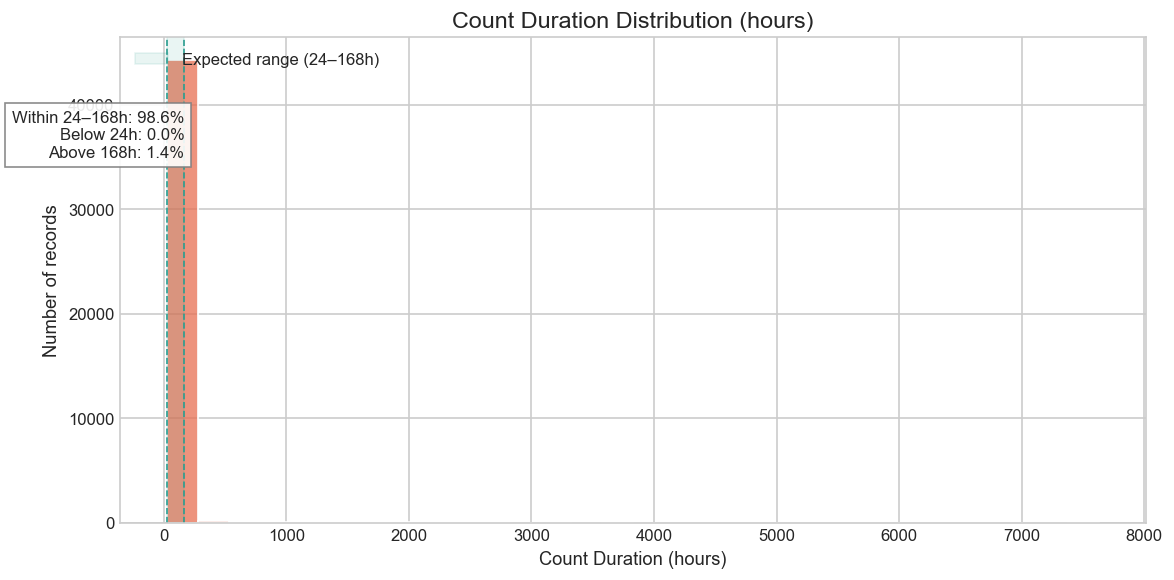

In [7]:
duration_summary = df["count_duration"].describe()
within_expected_pct = df["count_duration"].between(24, 168, inclusive="both").mean() * 100
below_expected_pct = (df["count_duration"] < 24).mean() * 100
above_expected_pct = (df["count_duration"] > 168).mean() * 100

print("Count duration summary (hours):")
display(duration_summary.to_frame("count_duration"))

print(f"Share within expected 24-168 hour range: {within_expected_pct:.2f}%")
print(f"Share below 24 hours: {below_expected_pct:.2f}%")
print(f"Share above 168 hours: {above_expected_pct:.2f}%")

fig, ax = plt.subplots(figsize=(10, 5))
count_dur = df["count_duration"].dropna()

sns.histplot(
    data=df.dropna(subset=["count_duration"]),
    x="count_duration",
    bins=30,
    color="#e76f51",
    edgecolor="white",
    ax=ax,
)
ax.axvspan(24, 168, color="#2a9d8f", alpha=0.1, label="Expected range (24–168h)")
ax.axvline(24, color="#2a9d8f", linestyle="--", linewidth=1)
ax.axvline(168, color="#2a9d8f", linestyle="--", linewidth=1)

ax.set_title("Count Duration Distribution (hours)")
ax.set_xlabel("Count Duration (hours)")
ax.set_ylabel("Number of records")

# Annotate key coverage percentages
text_x = count_dur.quantile(0.95)
text_y = ax.get_ylim()[1] * 0.85
ax.text(
    text_x,
    text_y,
    (
        f"Within 24–168h: {within_expected_pct:.1f}%\n"
        f"Below 24h: {below_expected_pct:.1f}%\n"
        f"Above 168h: {above_expected_pct:.1f}%"
    ),
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.9, edgecolor="gray"),
    fontsize=10,
)

ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


### Visual Description
This visual presents distribution of count duration. The horizontal axis reports count duration (hours), and the vertical axis reports frequency. Together, the figure provides a direct summary of the traffic pattern, model comparison, or operational outcome under study.

### Insight
The main value of this visual is that it makes relative differences immediately visible, which helps confirm whether the selected time window and location coverage are sufficient to support credible congestion analysis and forecasting. That perspective supports clearer discussion of congestion conditions, forecasting performance, and signal-timing decisions during presentation.

Count duration consistency matters because recurring traffic demand patterns are easier to compare when observation windows are reasonably standardized. Highly irregular durations do not prevent optimization-oriented analysis, but they do reduce comparability across locations and campaigns.

## Interpretation — Data Suitability Assessment
Temporal and spatial diagnostics indicate that the dataset is suitable for recurring-demand analysis in the pre-COVID baseline period. Missingness and collection irregularity are present but sufficiently transparent to support modeling with documented assumptions.

## Conclusion / Key Takeaways
- The 2015-2019 window provides the most stable baseline for recurring traffic behavior.
- Spatial coverage is broad enough for network-level and location-level capstone analysis.
- Missing values and irregular collection patterns are identifiable and manageable with explicit assumptions.
- The dataset is suitable for downstream feature engineering, forecasting, and signal strategy evaluation, with limitations clearly documented.